# Multiclass Student Performance Prediction with Explainable AI
**Name:** Fathima Aabidha Rifky

**Cardiff Met ID:** st20357374

**ICBT ID:** CL-MCSDS-CMU-10-04

**Dataset:** UCI Student Performance - https://archive.ics.uci.edu/dataset/320/student+performance

**Github Link** - https://github.com/AabidhaRifky/CL-MCSDS-CMU-10-04_DAS7000_student_performance_xai


## 1. Problem framing

Educators often need early signals to identify students who may struggle before the end of the academic year. This project builds a machine learning framework to predict a student’s final performance category and explains the main factors behind predictions using visual explainability.

### Prediction target
The dataset includes three grades for the course:
- **G1**: first period grade (early in the year)
- **G2**: second period grade (mid-year)
- **G3**: final grade (end of year)

We convert **G3** into a multiclass outcome:
- **Low**: 0 to 9
- **Medium**: 10 to 14
- **High**: 15 to 20

### Two-stage experiment
1. **Early model** predicts the final category using background and behavioural factors only (no G1, no G2).
2. **Mid-term model** predicts the final category using background factors plus academic history (includes G1 and G2).

We expect accuracy to improve in the mid-term model because G1 and G2 carry direct academic signal. We also expect the explanation patterns to shift.

## 2. Research aim and questions

This project aims to develop an explainable machine learning framework to predict a student’s final academic performance category (**Low, Medium, High**) using the **UCI Student Performance (Portuguese)** dataset. Beyond predictive accuracy, the project focuses on explainability to support trustworthy educational decision-making by identifying the key factors influencing predictions and presenting them through interpretable visual analytics.

### Research questions

- **RQ1:** To what extent can student performance be predicted using early-stage demographic and behavioural indicators before academic grades (**G1**, **G2**) are available?

- **RQ2:** How does predictive performance change when mid-term academic signals (**G1**, **G2**) are included compared with an early warning feature set?

- **RQ3:** Which factors most strongly influence predictions across the student population (**global explanations**), and how can individual predictions be justified (**local explanations**) using SHAP-based explainable AI?

- **RQ4:** What types of misclassification patterns occur between **Low**, **Medium**, and **High** categories particularly false negatives for the **Low (at-risk)** group and what do these errors imply for intervention decisions?

- **RQ5:** How reliable are the model’s predicted probabilities for decision support, as assessed using **calibration curves** and related reliability measures?

## 3. Setup

This notebook uses common Python libraries for data science and machine learning. If you are running in Google Colab, the installation cell below will ensure required packages are available.

In [3]:
# If running in Google Colab, install extra packages.
# If you already have these installed, you can skip this cell.

!pip -q install xgboost shap scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup complete.')

c:\Users\Aabidha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [6]:
# ================================
# Output Manager (saves figures, tables, text outputs, and models)
# ================================
import os, io, pickle
import pandas as pd
import matplotlib.pyplot as plt

class OutputManager:
    def __init__(self, base_dir="output"):
        self.base_dir = base_dir
        self.figures_dir = os.path.join(base_dir, "figures")
        self.tables_dir  = os.path.join(base_dir, "tables")
        self.text_dir    = os.path.join(base_dir, "text")
        self.models_dir  = os.path.join(base_dir, "models")
        self.best_dir    = os.path.join(base_dir, "best_model")

        for d in [self.figures_dir, self.tables_dir, self.text_dir, self.models_dir, self.best_dir]:
            os.makedirs(d, exist_ok=True)

        self._fig_counter = 0
        print(f"Outputs will be saved under: {os.path.abspath(base_dir)}")

    def save_fig(self, name=None, dpi=300):
        """Save the current matplotlib figure as PNG into output/figures."""
        self._fig_counter += 1
        if not name:
            name = f"figure_{self._fig_counter:03d}"
        path = os.path.join(self.figures_dir, f"{name}.png")
        plt.savefig(path, dpi=dpi, bbox_inches="tight")
        return path

    def save_df(self, obj, name, index=False):
        """Save a DataFrame/Series to CSV into output/tables."""
        if isinstance(obj, pd.Series):
            obj = obj.to_frame()
        if not isinstance(obj, pd.DataFrame):
            raise TypeError("save_df expects a pandas DataFrame or Series")
        path = os.path.join(self.tables_dir, f"{name}.csv")
        obj.to_csv(path, index=index)
        return path

    def save_text(self, text, name):
        """Save plain text into output/text."""
        path = os.path.join(self.text_dir, f"{name}.txt")
        with open(path, "w", encoding="utf-8") as f:
            f.write(text)
        return path

    def save_model(self, model_obj, filename, is_best=False):
        """Save a model/pipeline pickle into output/best_model or output/models."""
        target_dir = self.best_dir if is_best else self.models_dir
        path = os.path.join(target_dir, filename)
        with open(path, "wb") as f:
            pickle.dump(model_obj, f)
        return path

om = OutputManager(base_dir="output")


Outputs will be saved under: d:\AABIDHAA\DATA SCIENCE\PROJECTS\CL-MCSDS-CMU-10-04_DAS7000_student_performance_xai\output


## 4. Load the dataset (Portuguese only)

We use only `student-por.csv` to keep the study clean and reproducible.

Note: The UCI dataset also includes `student-mat.csv` and mentions that many students appear in both files. We do not merge the datasets here because there is no unique student identifier and merging can introduce leakage or mismatches.

### How to provide the file
Option A: Upload `student-por.csv` to Colab.
Option B: Place the CSV in the same folder as this notebook.

The dataset uses semicolon separators, so we will load it using `sep=';'`.

In [7]:
# Update the filename if needed
CSV_PATH = 'dataset/student-por.csv'

df = pd.read_csv(CSV_PATH, sep=';')

print('Dataset loaded.')
print('Shape:', df.shape)
df.head()

Dataset loaded.
Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 5. Quick dataset overview

We will inspect:
- data types
- missing values
- basic summary statistics

This builds confidence that the dataset is usable and helps us plan preprocessing.

In [8]:
import io
buf = io.StringIO()
df.info(buf=buf)
info_text = buf.getvalue()
print(info_text)
om.save_text(info_text, 'df_info')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

'output\\text\\df_info.txt'

In [9]:
# Missing values overview
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0].head(20)

Series([], dtype: int64)

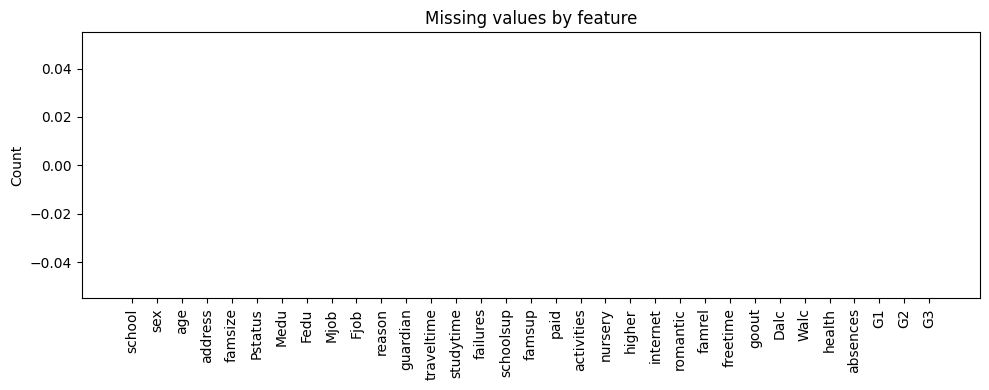

In [10]:
# Plot missing values per column (should be near zero for this dataset)
plt.figure(figsize=(10, 4))
plt.bar(missing_counts.index, missing_counts.values)
plt.title('Missing values by feature')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.tight_layout()
om.save_fig()
plt.show()

### Duplicate rows
We also check if there are exact duplicate rows in `por.csv`. This is different from the cross-file overlap note in the dataset description.

In [11]:
duplicate_rows = df.duplicated().sum()
print('Exact duplicate rows in por.csv:', duplicate_rows)

Exact duplicate rows in por.csv: 0


## 6. Define the prediction target (multiclass)

We convert **G3** into three categories:
- Low: 0 to 9
- Medium: 10 to 14
- High: 15 to 20

This matches a practical educator view of performance bands.

We will keep the original G3 for visualization, then create a new label column.

In [12]:
def grade_category(g3):
    if g3 <= 9:
        return 'Low'
    if g3 <= 14:
        return 'Medium'
    return 'High'

df['grade_cat'] = df['G3'].apply(grade_category)
# Numeric mapping only needed for XGBoost
LABEL_TO_NUM = {'Low': 0, 'Medium': 1, 'High': 2}
NUM_TO_LABEL = {v: k for k, v in LABEL_TO_NUM.items()}

df['grade_cat_num'] = df['grade_cat'].map(LABEL_TO_NUM)

df[['G3', 'grade_cat']].head()

,G3,grade_cat
0,11,Medium
1,11,Medium
2,12,Medium
3,14,Medium
4,13,Medium


In [13]:
df[['grade_cat', 'grade_cat_num']].drop_duplicates().sort_values('grade_cat_num')

,grade_cat,grade_cat_num
18,Low,0
0,Medium,1
8,High,2


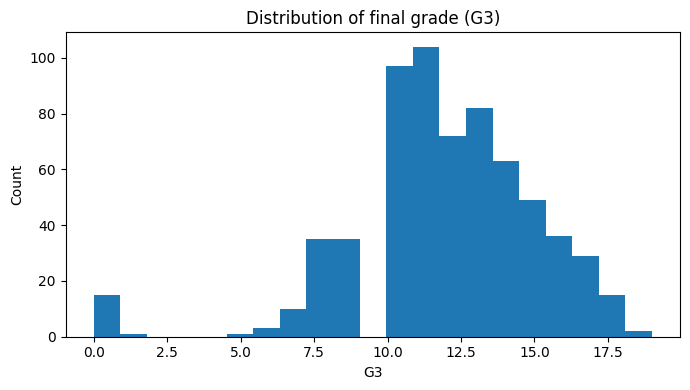

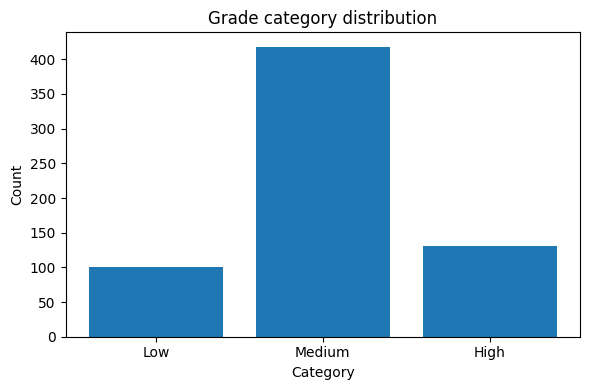

grade_cat
Low       100
Medium    418
High      131
Name: count, dtype: int64

In [14]:
# Distribution of raw final grades
plt.figure(figsize=(7, 4))
plt.hist(df['G3'], bins=21)
plt.title('Distribution of final grade (G3)')
plt.xlabel('G3')
plt.ylabel('Count')
plt.tight_layout()
om.save_fig()
plt.show()

# Distribution of grade categories
cat_counts = df['grade_cat'].value_counts().reindex(['Low', 'Medium', 'High'])

plt.figure(figsize=(6, 4))
plt.bar(cat_counts.index, cat_counts.values)
plt.title('Grade category distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
om.save_fig()
plt.show()

cat_counts

## 7. Exploratory Data Analysis (EDA)

This section looks for patterns that relate to performance.

We focus on features that are meaningful to educators and easy to interpret:
- absences
- studytime
- failures
- parental education
- support features (schoolsup, famsup)
- internet access

We will use simple, readable charts and write a short interpretation after each.

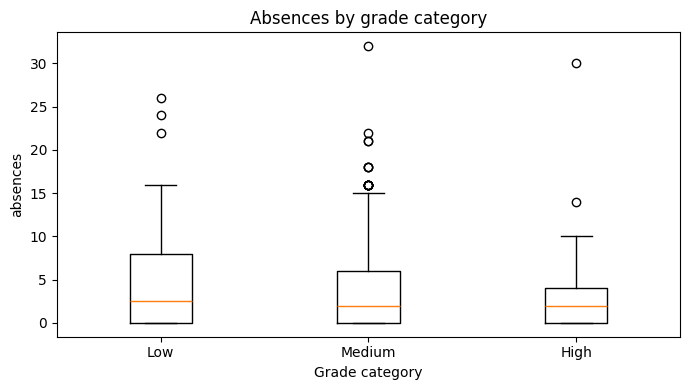

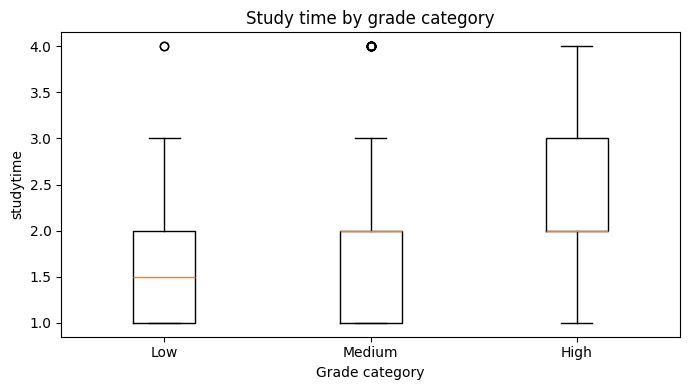

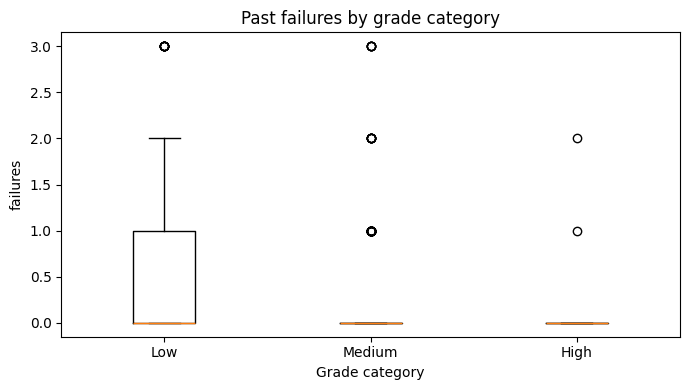

In [15]:
# Helper to plot a numeric feature by category using boxplots
def boxplot_by_category(feature, title):
    data = [
        df.loc[df['grade_cat'] == 'Low', feature].values,
        df.loc[df['grade_cat'] == 'Medium', feature].values,
        df.loc[df['grade_cat'] == 'High', feature].values,
    ]
    plt.figure(figsize=(7, 4))
    plt.boxplot(data, tick_labels=['Low','Medium','High'])
    plt.title(title)
    plt.xlabel('Grade category')
    plt.ylabel(feature)
    plt.tight_layout()
    om.save_fig()
    plt.show()

boxplot_by_category('absences', 'Absences by grade category')
boxplot_by_category('studytime', 'Study time by grade category')
boxplot_by_category('failures', 'Past failures by grade category')

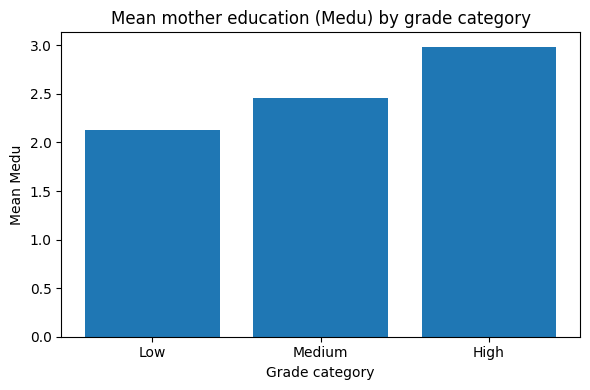

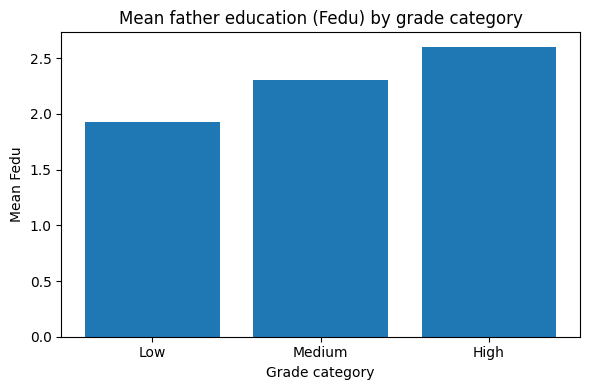

(grade_cat
 Low       2.130000
 Medium    2.459330
 High      2.984733
 Name: Medu, dtype: float64,
 grade_cat
 Low       1.930000
 Medium    2.303828
 High      2.603053
 Name: Fedu, dtype: float64)

In [16]:
# Parental education by category
def bar_mean_by_category(feature, title):
    means = df.groupby('grade_cat')[feature].mean().reindex(['Low', 'Medium', 'High'])
    plt.figure(figsize=(6, 4))
    plt.bar(means.index, means.values)
    plt.title(title)
    plt.xlabel('Grade category')
    plt.ylabel(f'Mean {feature}')
    plt.tight_layout()
    om.save_fig()
    plt.show()
    return means

medu_means = bar_mean_by_category('Medu', 'Mean mother education (Medu) by grade category')
fedu_means = bar_mean_by_category('Fedu', 'Mean father education (Fedu) by grade category')
medu_means, fedu_means

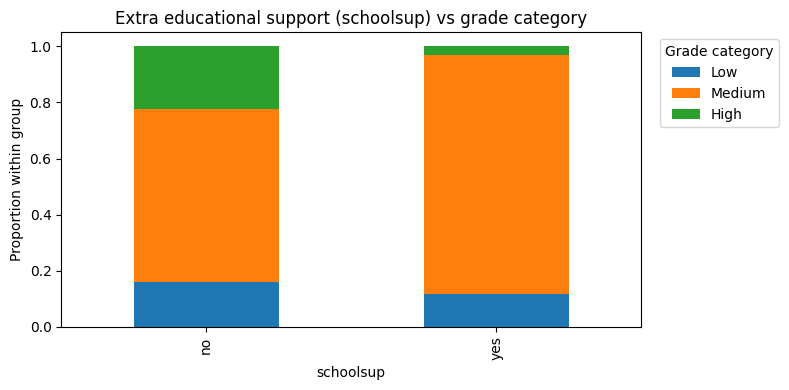

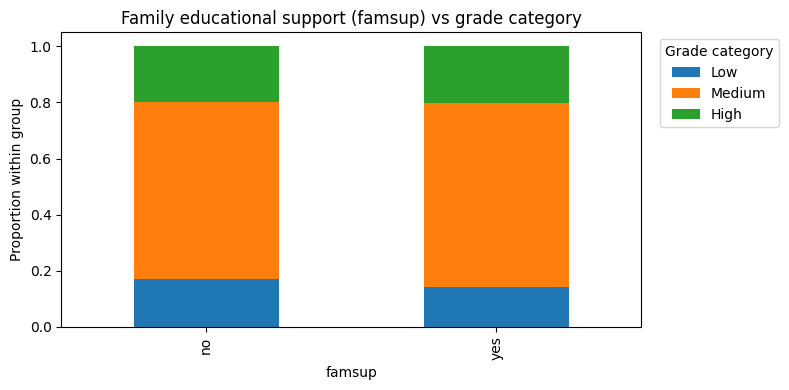

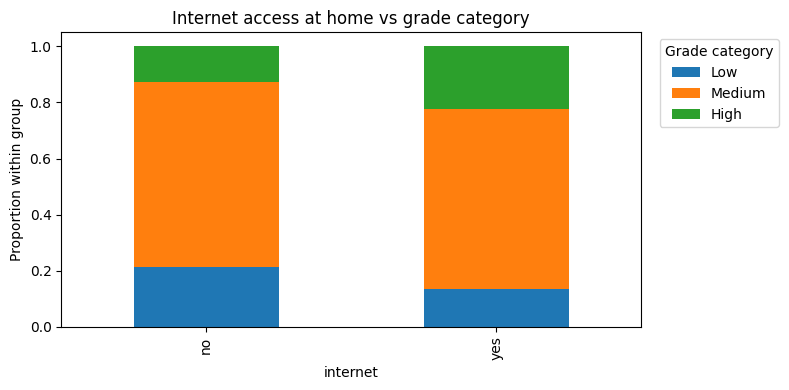

(grade_cat       Low    Medium      High
 schoolsup                              
 no         0.158348  0.619621  0.222031
 yes        0.117647  0.852941  0.029412,
 grade_cat       Low    Medium      High
 famsup                                 
 no         0.171315  0.629482  0.199203
 yes        0.143216  0.653266  0.203518,
 grade_cat       Low    Medium      High
 internet                               
 no         0.211921  0.662252  0.125828
 yes        0.136546  0.638554  0.224900)

In [17]:
# Categorical feature association with grade category using stacked bar chart
def stacked_bar(feature, title):
    ct = pd.crosstab(df[feature], df['grade_cat'], normalize='index').reindex(columns=['Low', 'Medium', 'High'])
    ct.plot(kind='bar', stacked=True, figsize=(8, 4))
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel('Proportion within group')
    plt.legend(title='Grade category', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    om.save_fig()
    plt.show()
    return ct

schoolsup_ct = stacked_bar('schoolsup', 'Extra educational support (schoolsup) vs grade category')
famsup_ct = stacked_bar('famsup', 'Family educational support (famsup) vs grade category')
internet_ct = stacked_bar('internet', 'Internet access at home vs grade category')

schoolsup_ct.head(), famsup_ct.head(), internet_ct.head()

### Correlation heatmap (numeric features)

Correlation helps us see which numeric variables tend to move together. For example, we expect G1, G2, and G3 to have strong relationships.

We will compute correlations only for numeric columns.

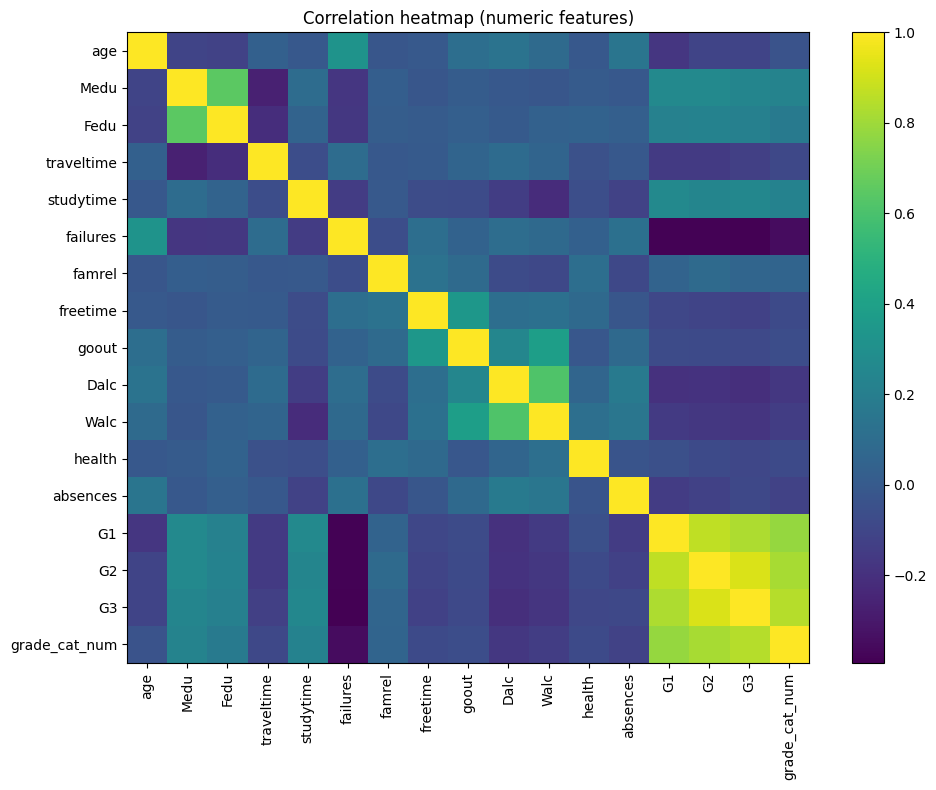

,G1,G2,G3
G3,0.826387,0.918548,1.000000
G2,0.864982,1.000000,0.918548
grade_cat_num,0.781725,0.819938,0.845897
G1,1.000000,0.864982,0.826387
studytime,0.260875,0.240498,0.249789
Medu,0.260472,0.264035,0.240151
Fedu,0.217501,0.225139,0.211800
famrel,0.048795,0.089588,0.063361
goout,-0.074053,-0.079469,-0.087641
absences,-0.147149,-0.124745,-0.091379


In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
om.save_fig()
plt.show()

corr[['G1', 'G2', 'G3']].sort_values(by='G3', ascending=False).head(10)

## 8. Preprocessing plan

We will:
- keep all features
- encode categorical variables using one-hot encoding
- standardize numeric variables only for Logistic Regression
- use a stratified 80/20 train-test split

We build pipelines so that preprocessing is applied consistently and reproducibly.

## 9. Define feature sets for the two-stage experiment

### Stage 1: Early model
Exclude **G1** and **G2** (no academic history).

### Stage 2: Mid-term model
Include **G1** and **G2**.

In both stages, the target is the grade category derived from **G3**.

In [19]:
TARGET_COL = 'grade_cat'

# Remove target and any target-derived columns to prevent leakage
DROP_COLS = ['G3', 'grade_cat', 'grade_cat_num']
all_features = [c for c in df.columns if c not in DROP_COLS]

# Early model excludes G1 and G2
early_features = [c for c in all_features if c not in ['G1', 'G2']]

# Mid-term includes G1 and G2
mid_features = all_features.copy()

print('Total features:', len(all_features))
print('Early features:', len(early_features))
print('Mid-term features:', len(mid_features))

early_features[:10], mid_features[:10]

Total features: 32
Early features: 30
Mid-term features: 32


(['school',
  'sex',
  'age',
  'address',
  'famsize',
  'Pstatus',
  'Medu',
  'Fedu',
  'Mjob',
  'Fjob'],
 ['school',
  'sex',
  'age',
  'address',
  'famsize',
  'Pstatus',
  'Medu',
  'Fedu',
  'Mjob',
  'Fjob'])

## 10. Train-test split (stratified 80/20)

We split the dataset once into training and testing sets.
Stratification keeps the Low, Medium, High proportions similar in both sets.

We will reuse the same split for all models within a stage to ensure fair comparison.

In [20]:
def make_split(features):
    X = df[features].copy()
    y = df[TARGET_COL].copy()
    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

X_train_e, X_test_e, y_train_e, y_test_e = make_split(early_features)
X_train_m, X_test_m, y_train_m, y_test_m = make_split(mid_features)

# Numeric y for XGBoost only (same split, just mapped labels)
y_train_e_xgb = y_train_e.map(LABEL_TO_NUM)
y_test_e_xgb  = y_test_e.map(LABEL_TO_NUM)

y_train_m_xgb = y_train_m.map(LABEL_TO_NUM)
y_test_m_xgb  = y_test_m.map(LABEL_TO_NUM)

print('Early split:', X_train_e.shape, X_test_e.shape)
print('Mid split:', X_train_m.shape, X_test_m.shape)

print('Early train distribution:')
print(y_train_e.value_counts(normalize=True).reindex(['Low','Medium','High']))
print('Early test distribution:')
print(y_test_e.value_counts(normalize=True).reindex(['Low','Medium','High']))

Early split: (519, 30) (130, 30)
Mid split: (519, 32) (130, 32)
Early train distribution:
grade_cat
Low       0.154143
Medium    0.643545
High      0.202312
Name: proportion, dtype: float64
Early test distribution:
grade_cat
Low       0.153846
Medium    0.646154
High      0.200000
Name: proportion, dtype: float64


## 11. Build preprocessing pipelines

We detect categorical and numeric columns for each stage.

- Categorical columns use one-hot encoding
- Numeric columns use scaling only for Logistic Regression

We will create:
- one pipeline for Logistic Regression
- one pipeline for Random Forest
- one pipeline for XGBoost

In [21]:
def get_column_types(X):
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    return cat_cols, num_cols

def make_preprocessor(cat_cols, num_cols, scale_numeric=False):
    transformers = []
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols))
    if scale_numeric:
        transformers.append(('num', StandardScaler(), num_cols))
    else:
        transformers.append(('num', 'passthrough', num_cols))
    return ColumnTransformer(transformers)

cat_e, num_e = get_column_types(X_train_e)
cat_m, num_m = get_column_types(X_train_m)

print('Early categorical:', len(cat_e), 'Early numeric:', len(num_e))
print('Mid categorical:', len(cat_m), 'Mid numeric:', len(num_m))

Early categorical: 17 Early numeric: 13
Mid categorical: 17 Mid numeric: 15


## 12. Model training and evaluation helper functions

We will evaluate all models using:
- Accuracy
- Macro F1
- Weighted F1
- Confusion matrix
- Multiclass ROC-AUC (one-vs-rest)

We keep the code modular to avoid repetition and make results consistent.

In [22]:
CLASS_ORDER = ['Low', 'Medium', 'High']

def reorder_proba_to_class_order(model, y_proba, class_order):
    """
    Ensures probability columns match the requested class_order.
    sklearn returns proba columns in model.classes_ order, which may differ.
    """
    # If this is a pipeline, classes_ is on the final estimator
    clf = model.named_steps['model'] if hasattr(model, "named_steps") else model
    model_classes = list(clf.classes_)
    idx = [model_classes.index(c) for c in class_order]
    return y_proba[:, idx]

def multiclass_roc_auc(y_true, y_proba_aligned, class_order=CLASS_ORDER):
    y_true_bin = label_binarize(y_true, classes=class_order)
    return roc_auc_score(y_true_bin, y_proba_aligned, average='macro', multi_class='ovr')

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
    disp.plot(values_format='d')
    plt.title(title)
    plt.tight_layout()
    om.save_fig()
    plt.show()

def plot_multiclass_roc(y_true, y_proba_aligned, title, class_order=CLASS_ORDER):
    y_true_bin = label_binarize(y_true, classes=class_order)
    plt.figure(figsize=(7, 5))
    for i, cls in enumerate(class_order):
        RocCurveDisplay.from_predictions(
            y_true_bin[:, i],
            y_proba_aligned[:, i],
            name=f'{cls} vs rest'
        )
    plt.title(title)
    plt.tight_layout()
    om.save_fig()
    plt.show()

def evaluate_model_text(name, model, X_train, X_test, y_train, y_test):
    """
    For Logistic Regression and Random Forest with text labels (Low, Medium, High).
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Align proba columns to CLASS_ORDER
    y_proba_aligned = reorder_proba_to_class_order(model, y_proba, CLASS_ORDER)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    auc = multiclass_roc_auc(y_test, y_proba_aligned, CLASS_ORDER)

    results = {
        'model': name,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'roc_auc_ovr_macro': auc
    }

    print('Model:', name)
    print('Accuracy:', round(acc, 4))
    print('Macro F1:', round(f1_macro, 4))
    print('Weighted F1:', round(f1_weighted, 4))
    print('ROC-AUC (OvR macro):', round(auc, 4))
    print('\nClassification report:\n')
    print(classification_report(y_test, y_pred, labels=CLASS_ORDER))

    plot_confusion(y_test, y_pred, f'Confusion matrix: {name}')
    plot_multiclass_roc(y_test, y_proba_aligned, f'ROC curves (OvR): {name}')

    return results, model

def evaluate_model_xgb(name, model, X_train, X_test, y_train_num, y_test_num):
    """
    For XGBoost with numeric labels (0,1,2) but reports in Low/Medium/High.
    """
    model.fit(X_train, y_train_num)
    y_pred_num = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # For XGBoost, classes_ should be [0,1,2]. Align them to numeric order [0,1,2]
    y_proba_aligned_num = reorder_proba_to_class_order(model, y_proba, [0, 1, 2])

    # Convert numeric to text for reporting
    y_test = y_test_num.map(NUM_TO_LABEL)
    y_pred = pd.Series(y_pred_num, index=y_test.index).map(NUM_TO_LABEL)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    # Convert aligned numeric proba to aligned text proba by mapping order 0,1,2 -> Low,Medium,High
    y_proba_aligned_text = y_proba_aligned_num  # columns are already [0,1,2] meaning Low,Medium,High by our mapping
    auc = multiclass_roc_auc(y_test_num, y_proba_aligned_num, [0, 1, 2])
    results = {
        'model': name,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'roc_auc_ovr_macro': auc
    }

    print('Model:', name)
    print('Accuracy:', round(acc, 4))
    print('Macro F1:', round(f1_macro, 4))
    print('Weighted F1:', round(f1_weighted, 4))
    print('ROC-AUC (OvR macro):', round(auc, 4))
    print('\nClassification report:\n')
    print(classification_report(y_test, y_pred, labels=CLASS_ORDER))

    plot_confusion(y_test, y_pred, f'Confusion matrix: {name}')
    plot_multiclass_roc(y_test, y_proba_aligned_text, f'ROC curves (OvR): {name}')

    return results, model

## 13. Experiment A: Early model (exclude G1 and G2)

In this stage, we predict the final performance category using background and behavioural features only.

This is the early warning scenario.

Model: Logistic Regression (Early)
Accuracy: 0.6692
Macro F1: 0.5106
Weighted F1: 0.6292
ROC-AUC (OvR macro): 0.7423

Classification report:

              precision    recall  f1-score   support

         Low       0.53      0.50      0.51        20
      Medium       0.70      0.87      0.78        84
        High       0.57      0.15      0.24        26

    accuracy                           0.67       130
   macro avg       0.60      0.51      0.51       130
weighted avg       0.65      0.67      0.63       130



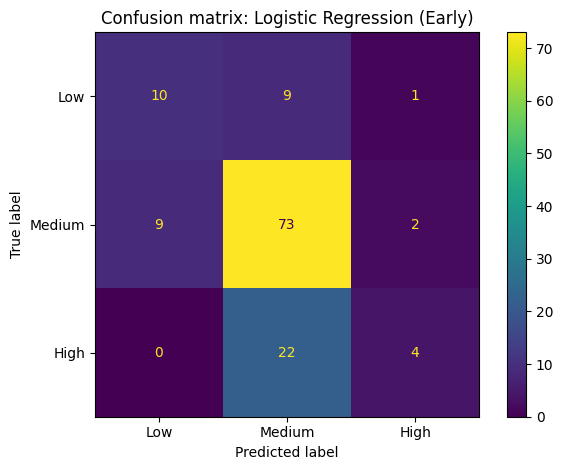

<Figure size 700x500 with 0 Axes>

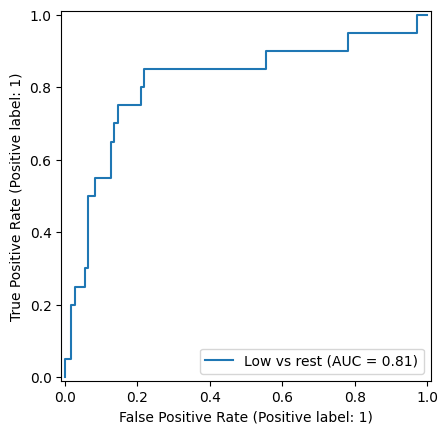

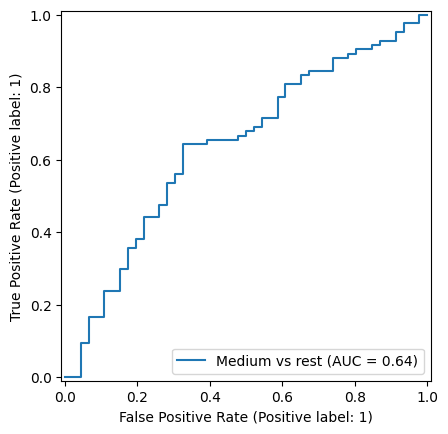

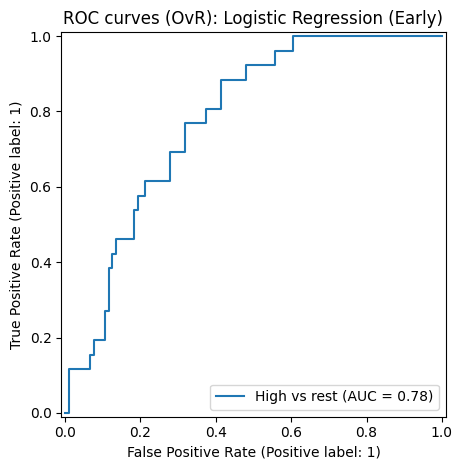

Model: Random Forest (Early)
Accuracy: 0.6
Macro F1: 0.3154
Weighted F1: 0.513
ROC-AUC (OvR macro): 0.7317

Classification report:

              precision    recall  f1-score   support

         Low       0.30      0.15      0.20        20
      Medium       0.64      0.89      0.75        84
        High       0.00      0.00      0.00        26

    accuracy                           0.60       130
   macro avg       0.31      0.35      0.32       130
weighted avg       0.46      0.60      0.51       130



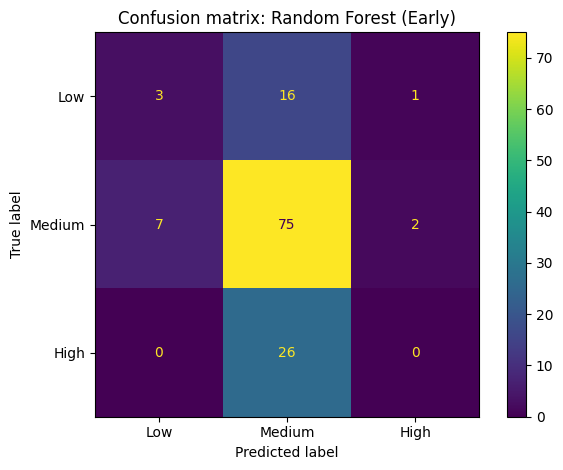

<Figure size 700x500 with 0 Axes>

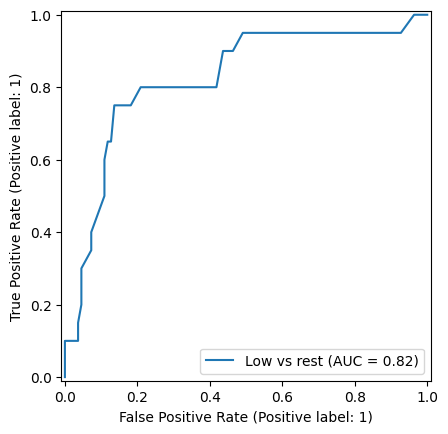

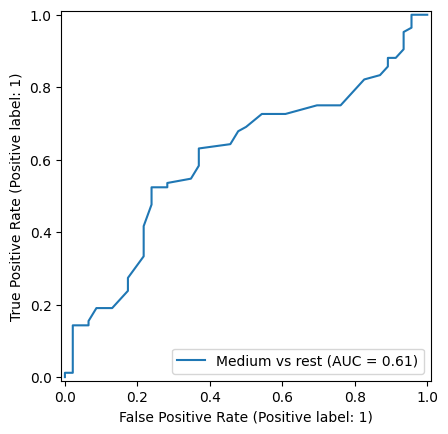

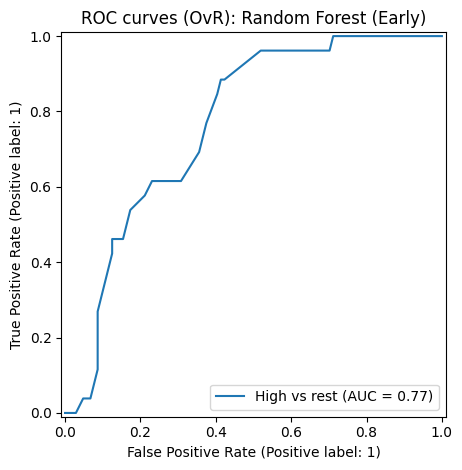

Model: XGBoost (Early)
Accuracy: 0.6077
Macro F1: 0.5024
Weighted F1: 0.6005
ROC-AUC (OvR macro): 0.7061

Classification report:

              precision    recall  f1-score   support

         Low       0.45      0.45      0.45        20
      Medium       0.70      0.74      0.72        84
        High       0.38      0.31      0.34        26

    accuracy                           0.61       130
   macro avg       0.51      0.50      0.50       130
weighted avg       0.60      0.61      0.60       130



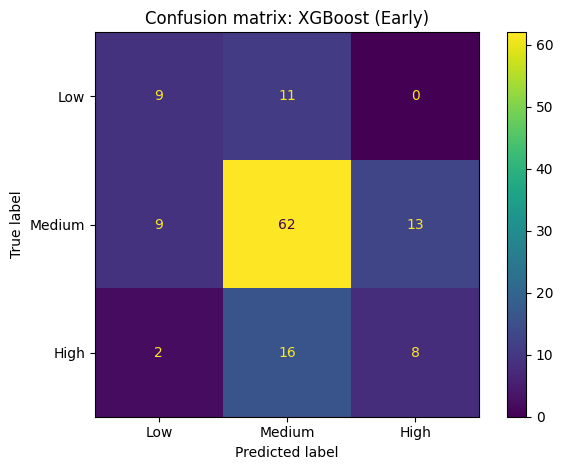

<Figure size 700x500 with 0 Axes>

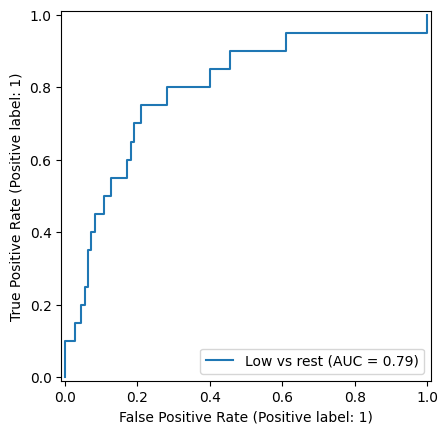

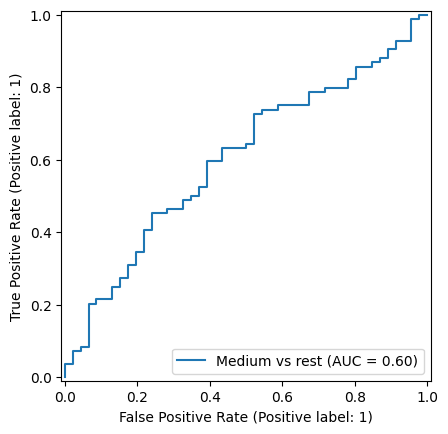

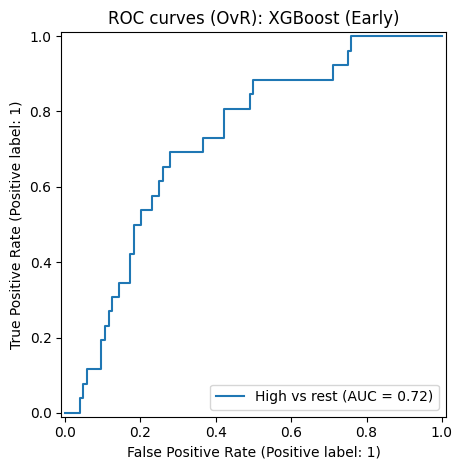

,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro
0,Logistic Regression (Early),0.669231,0.510613,0.629181,0.742296
2,XGBoost (Early),0.607692,0.502396,0.600455,0.706059
1,Random Forest (Early),0.600000,0.315423,0.512974,0.731657


In [23]:
# Build models for Early stage
pre_lr_e = make_preprocessor(cat_e, num_e, scale_numeric=True)
pre_tree_e = make_preprocessor(cat_e, num_e, scale_numeric=False)

lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
rf = RandomForestClassifier(random_state=RANDOM_STATE)

xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)

lr_pipe_e = Pipeline(steps=[('prep', pre_lr_e), ('model', lr)])
rf_pipe_e = Pipeline(steps=[('prep', pre_tree_e), ('model', rf)])
xgb_pipe_e = Pipeline(steps=[('prep', pre_tree_e), ('model', xgb)])

early_results = []
trained_early = {}

# Logistic Regression and Random Forest use text labels
res, fitted = evaluate_model_text('Logistic Regression (Early)', lr_pipe_e, X_train_e, X_test_e, y_train_e, y_test_e)
early_results.append(res)
trained_early['Logistic Regression (Early)'] = fitted

res, fitted = evaluate_model_text('Random Forest (Early)', rf_pipe_e, X_train_e, X_test_e, y_train_e, y_test_e)
early_results.append(res)
trained_early['Random Forest (Early)'] = fitted

# XGBoost uses numeric labels
res, fitted = evaluate_model_xgb('XGBoost (Early)', xgb_pipe_e, X_train_e, X_test_e, y_train_e_xgb, y_test_e_xgb)
early_results.append(res)
trained_early['XGBoost (Early)'] = fitted

early_results_df = pd.DataFrame(early_results).sort_values(by='f1_macro', ascending=False)
early_results_df

### Early stage comparison summary

We compare models using Macro F1 as a primary metric because it treats all classes fairly.
Accuracy alone can hide poor performance on minority categories.

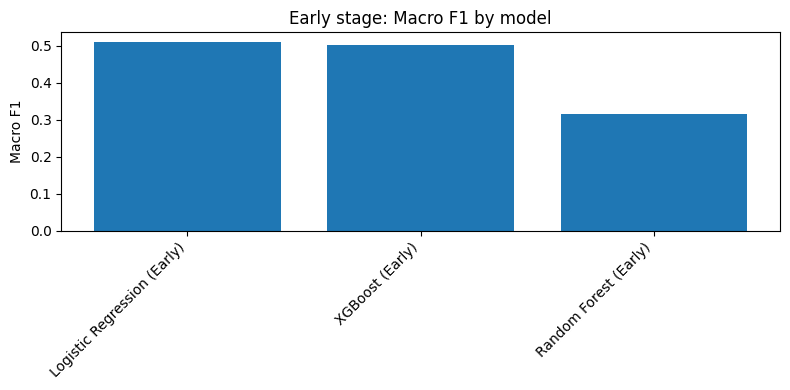

,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro
0,Logistic Regression (Early),0.669231,0.510613,0.629181,0.742296
2,XGBoost (Early),0.607692,0.502396,0.600455,0.706059
1,Random Forest (Early),0.600000,0.315423,0.512974,0.731657


In [24]:
plt.figure(figsize=(8, 4))
plt.bar(early_results_df['model'], early_results_df['f1_macro'])
plt.title('Early stage: Macro F1 by model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Macro F1')
plt.tight_layout()
om.save_fig()
plt.show()

early_results_df

## 14. Experiment B: Mid-term model (include G1 and G2)

In this stage, we include academic history (G1 and G2). This should improve prediction quality.

We train and evaluate the same three models, using the same train-test split strategy.

Model: Logistic Regression (Mid)
Accuracy: 0.8308
Macro F1: 0.7879
Weighted F1: 0.8295
ROC-AUC (OvR macro): 0.9479

Classification report:

              precision    recall  f1-score   support

         Low       0.70      0.70      0.70        20
      Medium       0.85      0.89      0.87        84
        High       0.86      0.73      0.79        26

    accuracy                           0.83       130
   macro avg       0.81      0.77      0.79       130
weighted avg       0.83      0.83      0.83       130



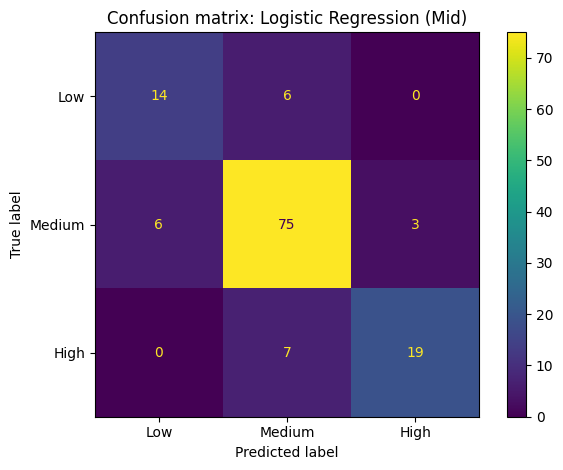

<Figure size 700x500 with 0 Axes>

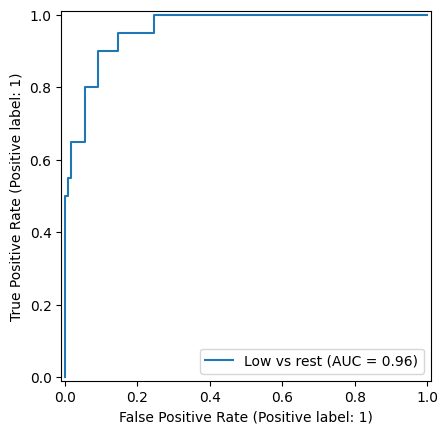

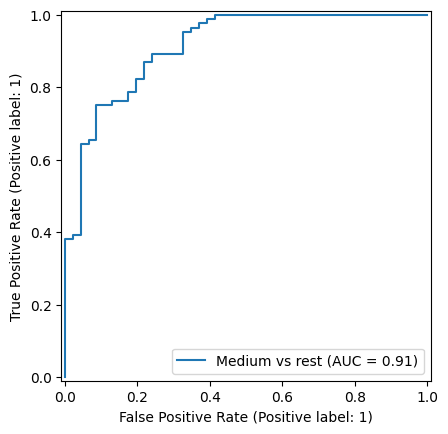

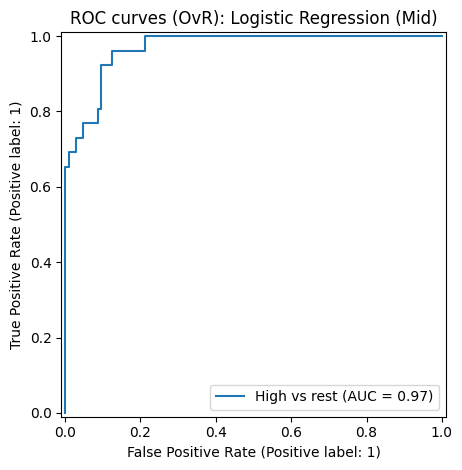

Model: Random Forest (Mid)
Accuracy: 0.8846
Macro F1: 0.8408
Weighted F1: 0.8793
ROC-AUC (OvR macro): 0.9533

Classification report:

              precision    recall  f1-score   support

         Low       0.92      0.60      0.73        20
      Medium       0.87      0.96      0.92        84
        High       0.92      0.85      0.88        26

    accuracy                           0.88       130
   macro avg       0.90      0.80      0.84       130
weighted avg       0.89      0.88      0.88       130



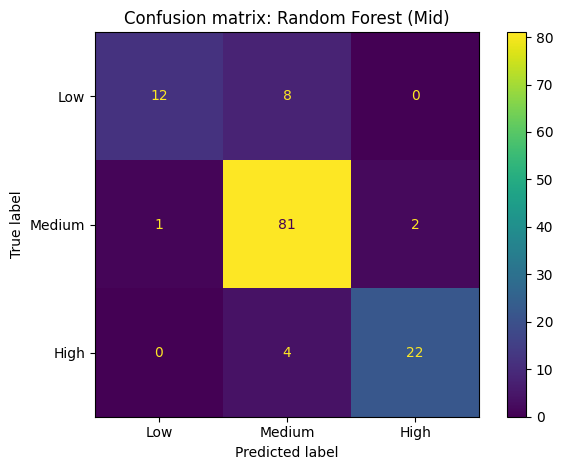

<Figure size 700x500 with 0 Axes>

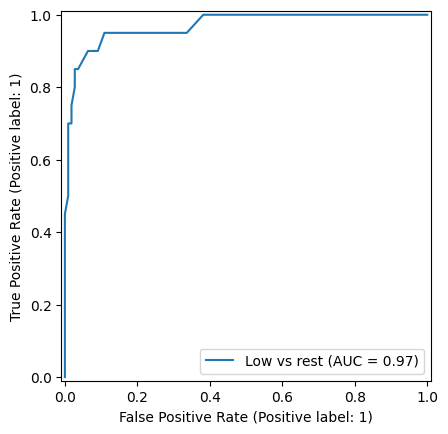

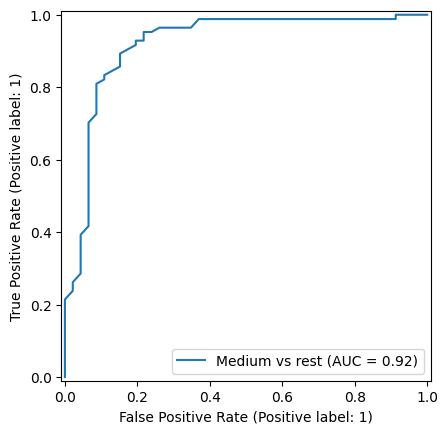

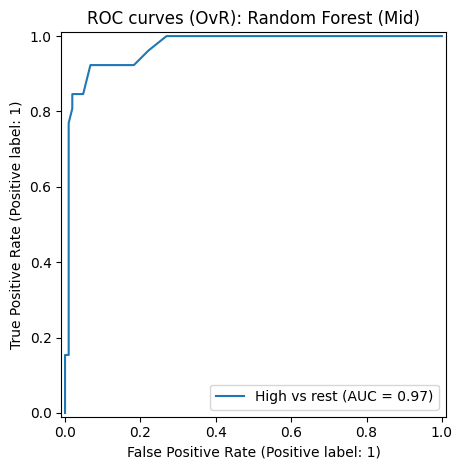

Model: XGBoost (Mid)
Accuracy: 0.8769
Macro F1: 0.8406
Weighted F1: 0.8746
ROC-AUC (OvR macro): 0.9428

Classification report:

              precision    recall  f1-score   support

         Low       0.82      0.70      0.76        20
      Medium       0.88      0.94      0.91        84
        High       0.91      0.81      0.86        26

    accuracy                           0.88       130
   macro avg       0.87      0.82      0.84       130
weighted avg       0.88      0.88      0.87       130



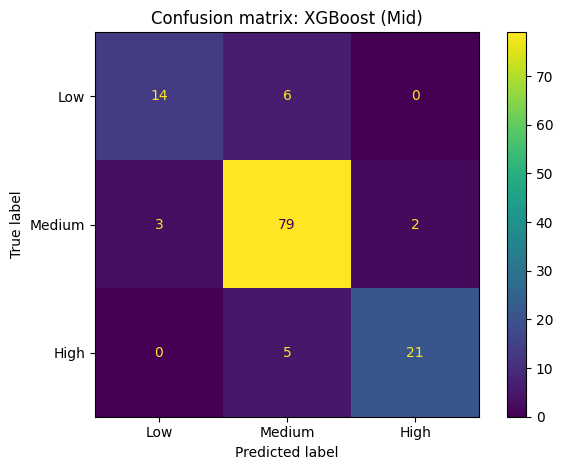

<Figure size 700x500 with 0 Axes>

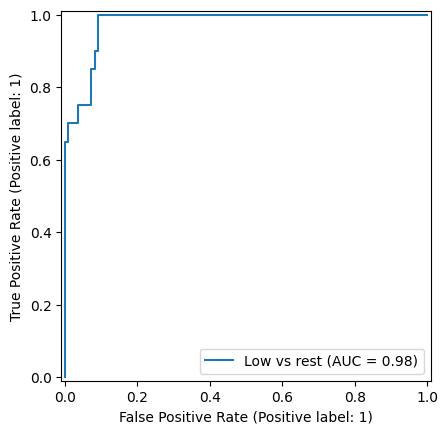

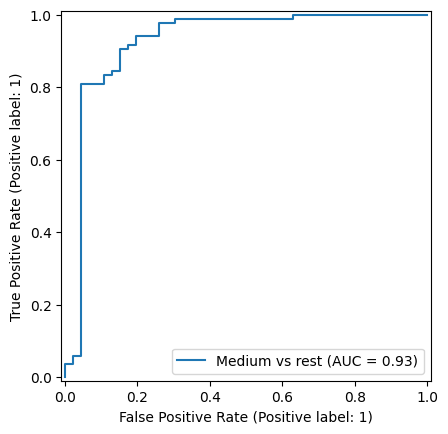

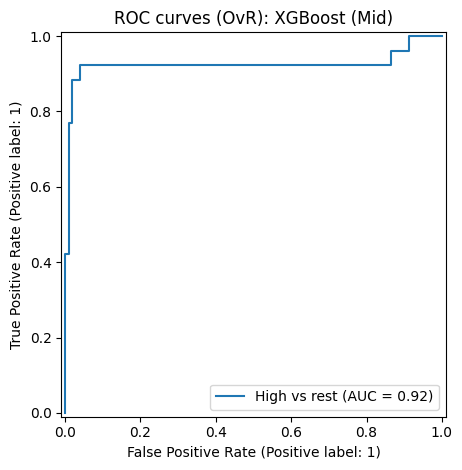

,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro
1,Random Forest (Mid),0.884615,0.840842,0.879283,0.953339
2,XGBoost (Mid),0.876923,0.840649,0.874590,0.942777
0,Logistic Regression (Mid),0.830769,0.787920,0.829532,0.947925


In [25]:
# Build models for Mid-term stage
pre_lr_m = make_preprocessor(cat_m, num_m, scale_numeric=True)
pre_tree_m = make_preprocessor(cat_m, num_m, scale_numeric=False)

lr_m = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
rf_m = RandomForestClassifier(random_state=RANDOM_STATE)

xgb_m = XGBClassifier(
    random_state=RANDOM_STATE,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss'
)

lr_pipe_m = Pipeline(steps=[('prep', pre_lr_m), ('model', lr_m)])
rf_pipe_m = Pipeline(steps=[('prep', pre_tree_m), ('model', rf_m)])
xgb_pipe_m = Pipeline(steps=[('prep', pre_tree_m), ('model', xgb_m)])

mid_results = []
trained_mid = {}

# Logistic Regression and Random Forest use text labels
res, fitted = evaluate_model_text('Logistic Regression (Mid)', lr_pipe_m, X_train_m, X_test_m, y_train_m, y_test_m)
mid_results.append(res)
trained_mid['Logistic Regression (Mid)'] = fitted

res, fitted = evaluate_model_text('Random Forest (Mid)', rf_pipe_m, X_train_m, X_test_m, y_train_m, y_test_m)
mid_results.append(res)
trained_mid['Random Forest (Mid)'] = fitted

# XGBoost uses numeric labels
res, fitted = evaluate_model_xgb('XGBoost (Mid)', xgb_pipe_m, X_train_m, X_test_m, y_train_m_xgb, y_test_m_xgb)
mid_results.append(res)
trained_mid['XGBoost (Mid)'] = fitted

mid_results_df = pd.DataFrame(mid_results).sort_values(by='f1_macro', ascending=False)
mid_results_df

### Mid-term stage comparison summary

We visualize Macro F1 to see which model performs best when G1 and G2 are included.

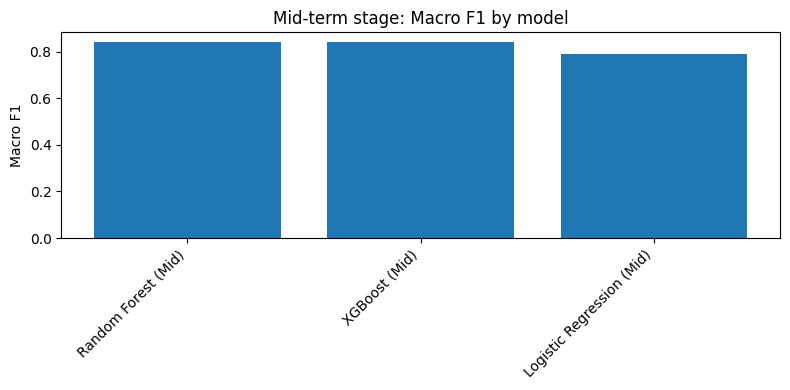

,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro
1,Random Forest (Mid),0.884615,0.840842,0.879283,0.953339
2,XGBoost (Mid),0.876923,0.840649,0.874590,0.942777
0,Logistic Regression (Mid),0.830769,0.787920,0.829532,0.947925


In [26]:
plt.figure(figsize=(8, 4))
plt.bar(mid_results_df['model'], mid_results_df['f1_macro'])
plt.title('Mid-term stage: Macro F1 by model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Macro F1')
plt.tight_layout()
om.save_fig()
plt.show()

mid_results_df

## 15. Early vs Mid-term comparison

This section directly answers the main experimental question:
Does performance improve when academic history (G1 and G2) is included?

We merge results into one comparison table and add a simple chart.

In [27]:
early_results_df2 = early_results_df.copy()
early_results_df2['stage'] = 'Early'

mid_results_df2 = mid_results_df.copy()
mid_results_df2['stage'] = 'Mid-term'

comparison_df = pd.concat([early_results_df2, mid_results_df2], ignore_index=True)
comparison_df = comparison_df[['stage', 'model', 'accuracy', 'f1_macro', 'f1_weighted', 'roc_auc_ovr_macro']]
comparison_df

,stage,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro
0,Early,Logistic Regression (Early),0.669231,0.510613,0.629181,0.742296
1,Early,XGBoost (Early),0.607692,0.502396,0.600455,0.706059
2,Early,Random Forest (Early),0.600000,0.315423,0.512974,0.731657
3,Mid-term,Random Forest (Mid),0.884615,0.840842,0.879283,0.953339
4,Mid-term,XGBoost (Mid),0.876923,0.840649,0.874590,0.942777
5,Mid-term,Logistic Regression (Mid),0.830769,0.787920,0.829532,0.947925


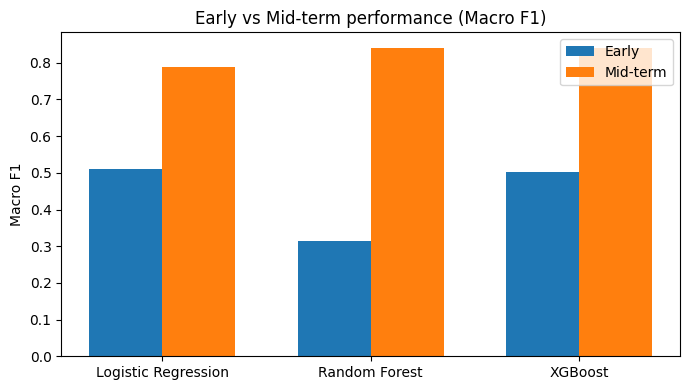

stage,Early,Mid-term
family,,
Logistic Regression,0.510613,0.787920
Random Forest,0.315423,0.840842
XGBoost,0.502396,0.840649


In [28]:
# Plot Early vs Mid-term for each model family
def family_name(model_name):
    if 'Logistic' in model_name:
        return 'Logistic Regression'
    if 'Random Forest' in model_name:
        return 'Random Forest'
    return 'XGBoost'

comparison_df['family'] = comparison_df['model'].apply(family_name)

pivot = comparison_df.pivot_table(index='family', columns='stage', values='f1_macro')
pivot = pivot.reindex(['Logistic Regression', 'Random Forest', 'XGBoost'])

plt.figure(figsize=(7, 4))
x = np.arange(len(pivot.index))
width = 0.35
plt.bar(x - width/2, pivot['Early'], width, label='Early')
plt.bar(x + width/2, pivot['Mid-term'], width, label='Mid-term')
plt.xticks(x, pivot.index, rotation=0)
plt.ylabel('Macro F1')
plt.title('Early vs Mid-term performance (Macro F1)')
plt.legend()
plt.tight_layout()
om.save_fig()
plt.show()

pivot

## 16. Select the best-performing model

We pick the best model using Macro F1 from the mid-term stage. This is the model we will explain using SHAP.

We keep XAI focused on the best model to keep the analysis clear and professional.

In [29]:
best_row = mid_results_df.sort_values(by='f1_macro', ascending=False).iloc[0]
best_model_name = best_row['model']
print('Best model selected:', best_model_name)
best_model = trained_mid[best_model_name]

best_row

Best model selected: Random Forest (Mid)


model                Random Forest (Mid)
accuracy                        0.884615
f1_macro                        0.840842
f1_weighted                     0.879283
roc_auc_ovr_macro               0.953339
Name: 1, dtype: object

## 17. Explainable AI with SHAP (best model only)

### What SHAP gives us
SHAP provides:
- Global explanations: which features matter most overall across all students.
- Local explanations: why the model predicted a specific category for a specific student.

For tree-based models such as Random Forest and XGBoost, SHAP is especially effective because the TreeExplainer method can accurately explain ensemble tree models. This makes it well suited for understanding how the best-performing model reaches its decisions.

If the best model is not tree-based, we can still apply SHAP, but the underlying explainer method may differ slightly depending on the model type.

In [30]:
# Prepare transformed feature matrix for SHAP
# We need access to the preprocessor and the final model.

prep = best_model.named_steps['prep']
clf = best_model.named_steps['model']

X_train_trans = prep.fit_transform(X_train_m)
X_test_trans = prep.transform(X_test_m)

# Build feature names after one-hot encoding
ohe = prep.named_transformers_['cat']
cat_features = cat_m
num_features = num_m

ohe_feature_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = ohe_feature_names + num_features

# Convert to dense for SHAP plotting if needed
X_test_trans_dense = X_test_trans
try:
    if hasattr(X_test_trans, 'toarray'):
        X_test_trans_dense = X_test_trans.toarray()
except Exception:
    pass

print('Transformed test shape:', np.array(X_test_trans_dense).shape)
print('Feature names count:', len(all_feature_names))

Transformed test shape: (130, 58)
Feature names count: 58


In [31]:
shap.initjs()

# Prefer TreeExplainer for tree-based models (XGB + RandomForest)
if isinstance(clf, (XGBClassifier, RandomForestClassifier)):
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer(X_test_trans_dense)   # returns Explanation
else:
    explainer = shap.Explainer(clf, X_train_trans)
    shap_values = explainer(X_test_trans_dense)

print('SHAP values computed.')

SHAP values computed.


### 17.1 Global explanation: SHAP summary plot

This plot shows which features contribute the most to predictions across the test set.
For multiclass models, SHAP returns values per class. We will display the summary for each class if available.

C:\Users\Aabidha\AppData\Local\Temp\ipykernel_14856\1025210735.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_trans_dense, feature_names=all_feature_names, show=False)


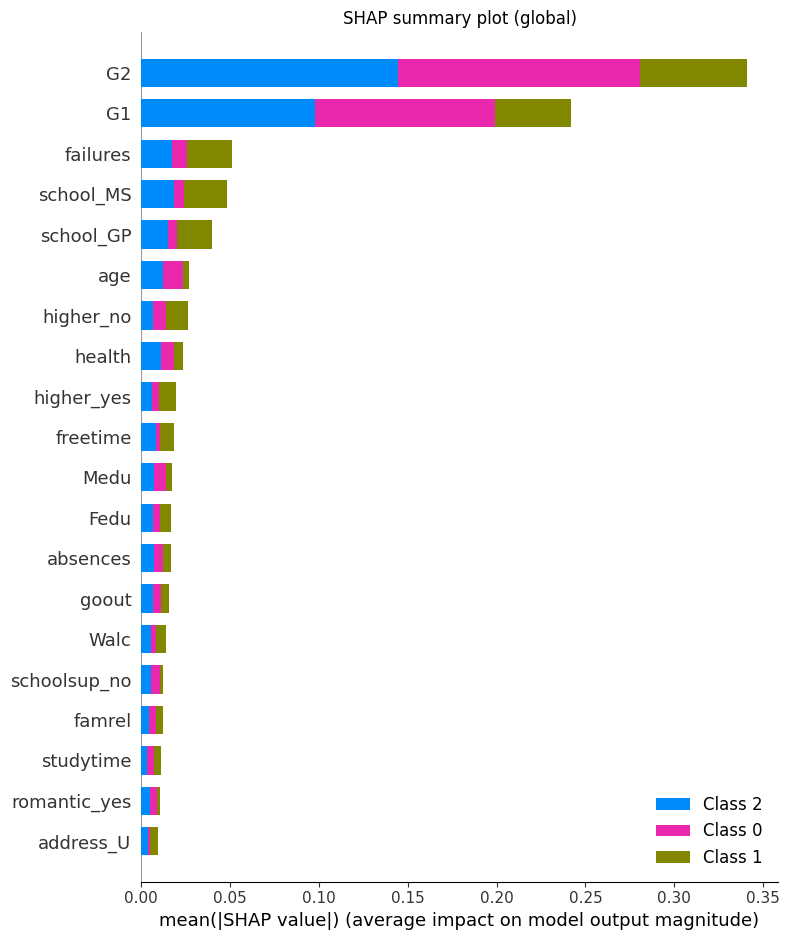

In [32]:
if isinstance(clf, XGBClassifier):
    # shap_values is a list: one array per class
    for i, cls in enumerate(CLASS_ORDER):
        plt.figure(figsize=(8, 5))
        shap.summary_plot(shap_values[i], X_test_trans_dense, feature_names=all_feature_names, show=False)
        plt.title(f'SHAP summary plot for class: {cls}')
        plt.tight_layout()
        om.save_fig()
        plt.show()
else:
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_test_trans_dense, feature_names=all_feature_names, show=False)
    plt.title('SHAP summary plot (global)')
    plt.tight_layout()
    om.save_fig()
    plt.show()

### 17.2 Local explanations: 3 example students

We explain three individual predictions:
- one predicted Low
- one predicted Medium
- one predicted High

This helps translate model reasoning into educator-friendly insights.

In [33]:
# Get predicted class for each student in the test set
y_test_pred = best_model.predict(X_test_m)
test_df = X_test_m.copy()
test_df['true'] = y_test_m.values
test_df['pred'] = y_test_pred

examples = {}
for cls in CLASS_ORDER:
    idxs = test_df.index[test_df['pred'] == cls].tolist()
    if len(idxs) > 0:
        examples[cls] = idxs[0]

print('Example indices by predicted class:', examples)

example_indices = [examples[c] for c in CLASS_ORDER if c in examples]
example_indices

Example indices by predicted class: {'Low': 572, 'Medium': 505, 'High': 314}


[572, 505, 314]

---
Predicted class: Low
True class: Low


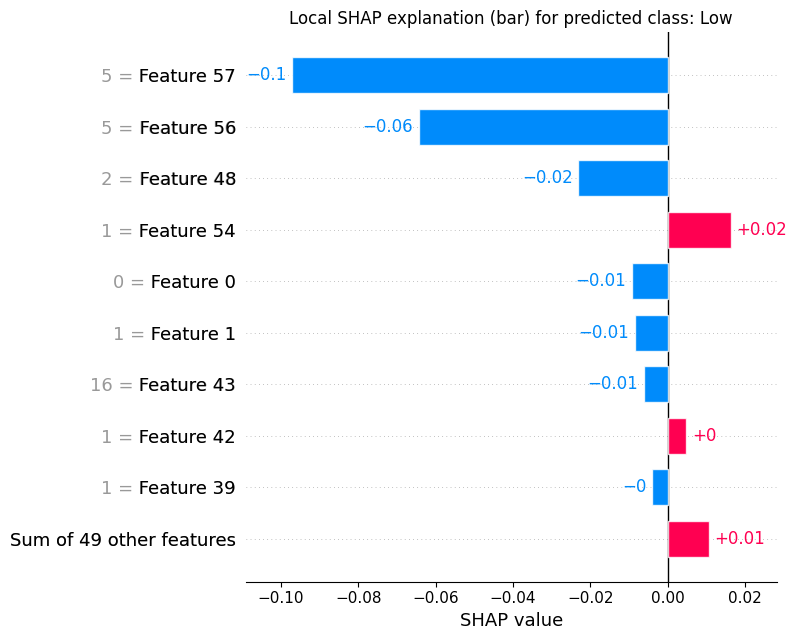

---
Predicted class: Medium
True class: Medium


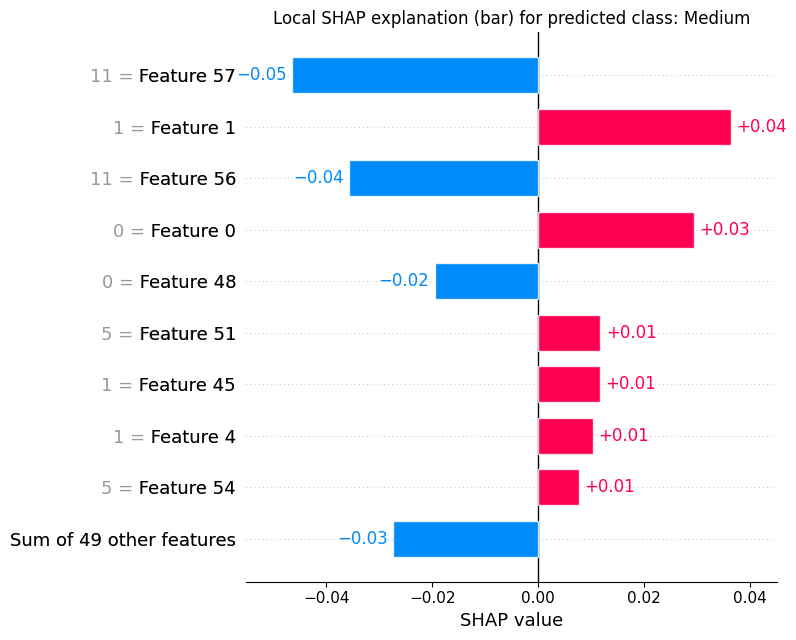

---
Predicted class: High
True class: High


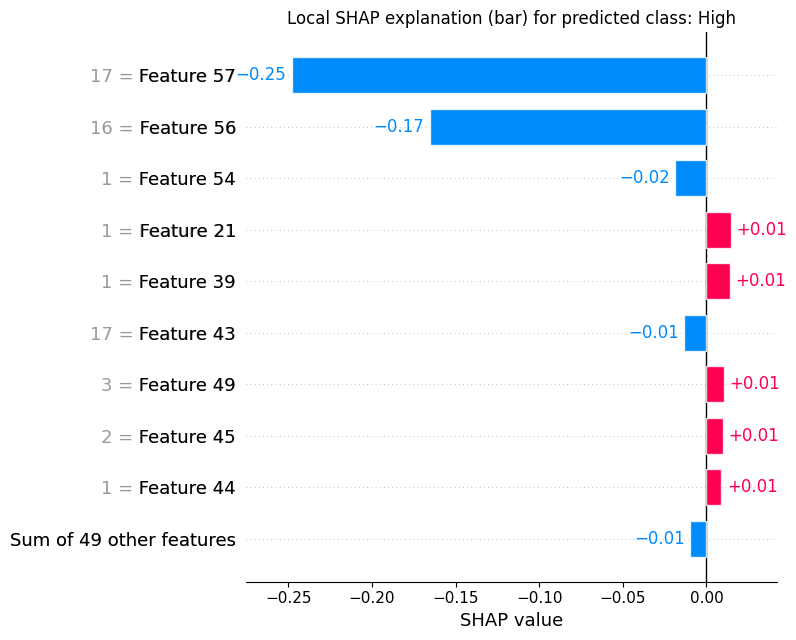

In [34]:
# Explain each example using SHAP
for cls in CLASS_ORDER:
    if cls not in examples:
        continue
    idx = examples[cls]
    row_position = list(X_test_m.index).index(idx)

    print('---')
    print('Predicted class:', cls)
    print('True class:', test_df.loc[idx, 'true'])

    x_row = X_test_trans_dense[row_position:row_position+1]

    if isinstance(clf, XGBClassifier):
        class_i = CLASS_ORDER.index(cls)
        plt.figure(figsize=(8, 5))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values[class_i][row_position],
                base_values=explainer.expected_value[class_i],
                data=x_row[0],
                feature_names=all_feature_names
            ),
            show=False
        )
        plt.title(f'Local SHAP explanation (waterfall) for predicted class: {cls}')
        plt.tight_layout()
        om.save_fig()
        plt.show()
    else:
        class_i = CLASS_ORDER.index(cls)
        shap.plots.bar(shap_values[row_position, :, class_i], show=False)
        plt.title(f'Local SHAP explanation (bar) for predicted class: {cls}')
        plt.tight_layout()
        om.save_fig()
        plt.show()

## 18. Calibration and trust check (best model)

Calibration checks whether predicted probabilities match real outcomes.
For multiclass problems, calibration is usually evaluated one class at a time using one-vs-rest.

We will plot calibration curves for each class.
If the curve stays close to the diagonal, predicted probabilities are reliable.

This supports trustworthy analytics because it helps educators understand whether the model is overconfident.

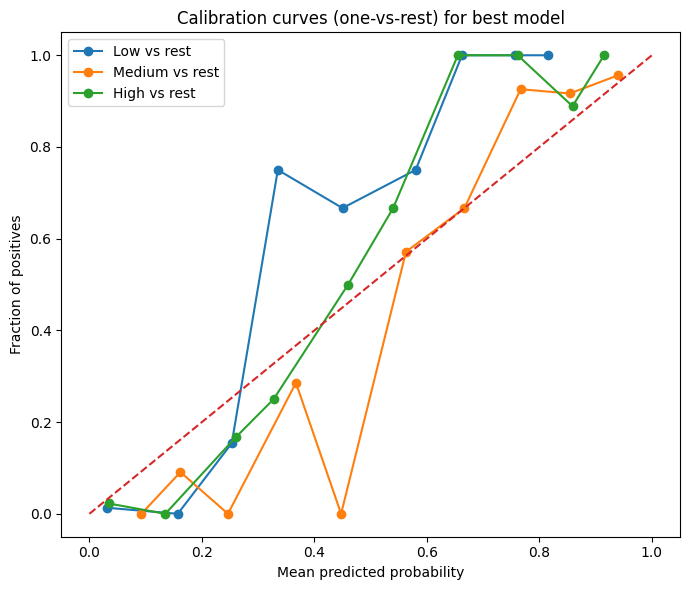

In [35]:
# Predicted probabilities for the best model on the mid-term test set (aligned to CLASS_ORDER)
proba_raw = best_model.predict_proba(X_test_m)
proba = reorder_proba_to_class_order(best_model, proba_raw, CLASS_ORDER)
y_true = y_test_m.values

# Plot calibration per class using one-vs-rest
plt.figure(figsize=(7, 6))
for i, cls in enumerate(CLASS_ORDER):
    y_bin = (y_true == cls).astype(int)
    prob_cls = proba[:, i]
    frac_pos, mean_pred = calibration_curve(y_bin, prob_cls, n_bins=10, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o', label=f'{cls} vs rest')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Calibration curves (one-vs-rest) for best model')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.legend()
plt.tight_layout()
om.save_fig()
plt.show()

In [36]:
clf = best_model.named_steps["model"]
print("Model classes_ order:", list(clf.classes_))
print("Your CLASS_ORDER:", CLASS_ORDER)

Model classes_ order: ['High', 'Low', 'Medium']
Your CLASS_ORDER: ['Low', 'Medium', 'High']


In [37]:
print("proba columns aligned to:", CLASS_ORDER)
print("first row probs (Low, Medium, High):", proba[0])
print("sum:", proba[0].sum())

proba columns aligned to: ['Low', 'Medium', 'High']
first row probs (Low, Medium, High): [0.13 0.79 0.08]
sum: 1.0


## 19. Final summary tables

We present clean summary tables for reporting:
- Early stage results
- Mid-term stage results
- Combined comparison

These tables can be copied into the report with minimal editing.

In [38]:
print('Early stage results:')
display(early_results_df)

print('Mid-term stage results:')
display(mid_results_df)

print('Combined comparison:')
display(comparison_df.sort_values(by=['stage', 'f1_macro'], ascending=[True, False]))

Early stage results:


,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro
0,Logistic Regression (Early),0.669231,0.510613,0.629181,0.742296
2,XGBoost (Early),0.607692,0.502396,0.600455,0.706059
1,Random Forest (Early),0.600000,0.315423,0.512974,0.731657


Mid-term stage results:


,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro
1,Random Forest (Mid),0.884615,0.840842,0.879283,0.953339
2,XGBoost (Mid),0.876923,0.840649,0.874590,0.942777
0,Logistic Regression (Mid),0.830769,0.787920,0.829532,0.947925


Combined comparison:


,stage,model,accuracy,f1_macro,f1_weighted,roc_auc_ovr_macro,family
0,Early,Logistic Regression (Early),0.669231,0.510613,0.629181,0.742296,Logistic Regression
1,Early,XGBoost (Early),0.607692,0.502396,0.600455,0.706059,XGBoost
2,Early,Random Forest (Early),0.600000,0.315423,0.512974,0.731657,Random Forest
3,Mid-term,Random Forest (Mid),0.884615,0.840842,0.879283,0.953339,Random Forest
4,Mid-term,XGBoost (Mid),0.876923,0.840649,0.874590,0.942777,XGBoost
5,Mid-term,Logistic Regression (Mid),0.830769,0.787920,0.829532,0.947925,Logistic Regression


### 20. Model Saving and Artifact Management

To support reproducibility and structured experiment management, trained models were exported and stored in organised output directories. The best-performing model (identified during evaluation) was saved separately from the other trained models to simplify deployment and reuse.

The best model was stored in the **output/best_model** directory, while all additional trained models from the early-stage and mid-term experiments were stored in the **output/models** directory. This separation allows easy identification of the final selected model while preserving other trained models for comparison and future experimentation.

Saving the models using Python’s **pickle** library ensures that the entire trained pipeline including preprocessing steps and model parameters can be reloaded later without retraining. This approach supports experiment reproducibility, model auditing, and potential deployment in real-world applications.

For convenience during experimentation in Google Colab, the best-performing model was also made available for download directly from the notebook environment.

In [39]:
# --- Save models to structured output folders (best_model + other models) ---

import pickle
import os

# 1) Save BEST model to output/best_model
best_model_filename = f"best_model_{best_model_name}.pkl"
best_model_path = om.save_model(best_model, best_model_filename, is_best=True)
print("Saved BEST model to:", best_model_path)

# 2) Save other trained models (if available) to output/models
#    This makes the project reproducible and keeps all model artifacts together.
if "trained_early" in globals() and isinstance(trained_early, dict):
    for name, mdl in trained_early.items():
        fname = f"model_{name}_Early.pkl"
        path = om.save_model(mdl, fname, is_best=False)
    print(f"Saved {len(trained_early)} early-stage model(s) to:", om.models_dir)

if "trained_mid" in globals() and isinstance(trained_mid, dict):
    for name, mdl in trained_mid.items():
        fname = f"model_{name}_Mid.pkl"
        path = om.save_model(mdl, fname, is_best=False)
    print(f"Saved {len(trained_mid)} mid-stage model(s) to:", om.models_dir)

# 3) Optional: download the BEST model from Colab
try:
    from google.colab import files
    files.download(best_model_path)
except Exception as e:
    print("Colab download skipped:", e)


Saved BEST model to: output\best_model\best_model_Random Forest (Mid).pkl
Saved 3 early-stage model(s) to: output\models
Saved 3 mid-stage model(s) to: output\models
Colab download skipped: No module named 'google.colab'


In [40]:
# Monkeypatch for old sklearn private class name when unpickling models
import sklearn.compose._column_transformer as _ct
if not hasattr(_ct, "_RemainderColsList"):
    class _RemainderColsList(list):
        pass
    _ct._RemainderColsList = _RemainderColsList

# Then load model
import pickle
with open("models/best_model_Random Forest (Mid).pkl", "rb") as f:
    model = pickle.load(f)

c:\Users\Aabidha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Aabidha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Aabidha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpick

In [41]:
# Load model (if you already loaded it, skip this)
import pickle
with open("models/best_model_Random Forest (Mid).pkl", "rb") as f:
    model = pickle.load(f)

# Predict on Mid-term test set
pred = model.predict(X_test_m)

from sklearn.metrics import accuracy_score, f1_score, classification_report
print("Accuracy:", accuracy_score(y_test_m, pred))
print("Macro F1:", f1_score(y_test_m, pred, average="macro"))
report_text = classification_report(y_test_m, pred)
print(report_text)
om.save_text(report_text, 'classification_report_best_model')


Accuracy: 0.8846153846153846
Macro F1: 0.8408423215202877
              precision    recall  f1-score   support

        High       0.92      0.85      0.88        26
         Low       0.92      0.60      0.73        20
      Medium       0.87      0.96      0.92        84

    accuracy                           0.88       130
   macro avg       0.90      0.80      0.84       130
weighted avg       0.89      0.88      0.88       130



'output\\text\\classification_report_best_model.txt'

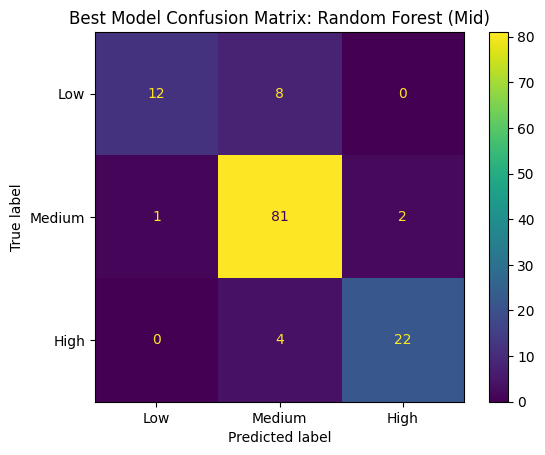

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred = model.predict(X_test_m)

cm = confusion_matrix(y_test_m, pred, labels=['Low','Medium','High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low','Medium','High'])
disp.plot(values_format='d')
plt.title("Best Model Confusion Matrix: Random Forest (Mid)")
om.save_fig()
plt.show()

### 21. Results Folder Creation

A dedicated `results/` directory was created to store key output artefacts generated during evaluation. Organising outputs into a single folder improves reproducibility and ensures that important figures and tables can be easily located for reporting and GitHub submission.

In [43]:
import os

os.makedirs("results", exist_ok=True)
print("results folder created.")

results folder created.


### 22. Confusion Matrix Export (Best Model)

To provide clear evidence of test-set performance and class-wise error patterns, a confusion matrix was computed for the best-performing model using the Mid-term test split (`X_test_m`, `y_test_m`). The confusion matrix was then exported as a high-resolution PNG file (`results/confusion_matrix.png`) to support inclusion in the report and the reproducibility pack.

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict again (if needed)
pred = model.predict(X_test_m)

cm = confusion_matrix(y_test_m, pred, labels=['Low','Medium','High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Low','Medium','High'])

plt.figure(figsize=(6,5))
disp.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest (Mid)")
plt.tight_layout()

plt.savefig("results/confusion_matrix.png", dpi=300)
plt.close()

print("Confusion matrix saved.")

Confusion matrix saved.


<Figure size 600x500 with 0 Axes>

### 23. Performance Metrics Table Export

Key evaluation metrics for the best model were summarised in a compact performance table, including Accuracy, Macro F1-score, and Weighted F1-score. This table was exported as a PNG image (`results/performance_table.png`) to provide a clear, report-ready summary of model performance and to support transparent model benchmarking.

In [45]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Compute metrics
accuracy = accuracy_score(y_test_m, pred)
f1_macro = f1_score(y_test_m, pred, average='macro')
f1_weighted = f1_score(y_test_m, pred, average='weighted')

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Weighted F1"],
    "Value": [accuracy, f1_macro, f1_weighted]
})

# Save as image
fig, ax = plt.subplots(figsize=(5,2))
ax.axis('off')
table = ax.table(cellText=performance_df.values,
                 colLabels=performance_df.columns,
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.savefig("results/performance_table.png", dpi=300, bbox_inches='tight')
plt.close()

print("Performance table saved.")

Performance table saved.


In [46]:
from IPython.display import FileLink, display
display(FileLink('results/confusion_matrix.png'))
display(FileLink('results/performance_table.png'))

d:\AABIDHAA\DATA SCIENCE\PROJECTS\CL-MCSDS-CMU-10-04_DAS7000_student_performance_xai\results\confusion_matrix.png

d:\AABIDHAA\DATA SCIENCE\PROJECTS\CL-MCSDS-CMU-10-04_DAS7000_student_performance_xai\results\performance_table.png

### 24. Bulk Export of Tables and Text Outputs

To support reproducibility and auditability, a bulk export routine was executed to save all DataFrames and Series objects produced during the notebook run (e.g., model comparison tables, intermediate summaries, and evaluation outputs). These artefacts were automatically exported into a structured output directory via the output manager, and an export summary text file was generated to confirm the number of tables saved.

In [47]:
# ================================
# BULK EXPORT: Save all DataFrames/Series + key text outputs
# (Run this before Key Findings)
# ================================
import pandas as pd

saved = {"tables": [], "text": []}

# Save every DataFrame/Series currently in memory into output/tables
for var_name, var_val in list(globals().items()):
    try:
        if isinstance(var_val, pd.DataFrame):
            path = om.save_df(var_val, var_name)
            saved["tables"].append(path)
        elif isinstance(var_val, pd.Series):
            path = om.save_df(var_val, var_name)
            saved["tables"].append(path)
    except Exception:
        # skip objects that can't be serialized to CSV cleanly
        pass

# Save a quick run summary
summary_lines = []
summary_lines.append("Bulk export completed.")
summary_lines.append(f"Saved tables: {len(saved['tables'])}")
summary_text = "\n".join(summary_lines)
om.save_text(summary_text, "export_summary")

print(summary_text)


Bulk export completed.
Saved tables: 45


### 25. Reproducibility Pack Generation

To meet reproducibility requirements, a structured reproducibility pack was generated in a dedicated `repro_pack/` folder. The pack includes:
- `cleaned_data.csv` – the cleaned dataset used for analysis and modelling,
- `data_dictionary.md` – an auto-generated data dictionary listing columns, data types, and missing values,
- `cleaning_log.csv` – a concise log of key preprocessing and modelling steps,
- `figure_index.csv` – an index of all saved figure files with portable paths.

This pack enables verification of results and supports transparent submission via GitHub.

In [48]:
# ===============================
# Reproducibility Pack Exporter
# ===============================

import os
import glob
import pandas as pd
from datetime import datetime

PACK_DIR = "repro_pack"
os.makedirs(PACK_DIR, exist_ok=True)

print("Creating reproducibility pack...")

# -------------------------
# 1) cleaned_data.csv
# -------------------------
try:
    df_cleaned = df.copy()
    df_cleaned.to_csv(f"{PACK_DIR}/cleaned_data.csv", index=False)
    print("Saved cleaned_data.csv")
except:
    print("Skipping cleaned_data.csv (df not found)")

# -------------------------
# 2) data_dictionary.md
# -------------------------
try:
    lines = []
    lines.append("# Data Dictionary\n")
    lines.append(f"_Generated {datetime.now()}_\n\n")
    lines.append("| Column | Type | Missing |\n")
    lines.append("|---|---|---|\n")

    for col in df.columns:
        dtype = str(df[col].dtype)
        missing = int(df[col].isna().sum())
        lines.append(f"| {col} | {dtype} | {missing} |\n")

    with open(f"{PACK_DIR}/data_dictionary.md", "w") as f:
        f.writelines(lines)

    print("Saved data_dictionary.md")

except:
    print("Skipping data dictionary (df not found)")

# -------------------------
# 3) cleaning_log.csv
# -------------------------
cleaning_steps = [
    ["1","Load dataset","Loaded student-por.csv"],
    ["2","Target engineering","Created Low/Medium/High from G3"],
    ["3","Feature selection","Defined early and mid feature sets"],
    ["4","Preprocessing","OneHotEncoder + scaling where needed"],
    ["5","Train-test split","Stratified split random_state=42"],
    ["6","Model training","LR, RF, XGBoost models trained"],
    ["7","Evaluation","Accuracy, F1, ROC-AUC"],
    ["8","Model persistence","Best model saved as pickle"]
]

pd.DataFrame(cleaning_steps,
             columns=["step","action","details"]
            ).to_csv(f"{PACK_DIR}/cleaning_log.csv",index=False)

print("Saved cleaning_log.csv")

# -------------------------
# 4) figure_index.csv
# -------------------------
FIG_DIR = "output/figures"
fig_files = sorted(glob.glob(f"{FIG_DIR}/*.png"))

fig_list = []
for i,f in enumerate(fig_files,1):
    fig_list.append({
        "figure_no": i,
        "filename": f
    })

pd.DataFrame(fig_list).to_csv(f"{PACK_DIR}/figure_index.csv",index=False)

print("Saved figure_index.csv")

print("\nReproducibility pack complete:", PACK_DIR)

Creating reproducibility pack...
Saved cleaned_data.csv
Saved data_dictionary.md
Saved cleaning_log.csv
Saved figure_index.csv

Reproducibility pack complete: repro_pack


### 26. Manual Test Inputs for Model Prediction

To demonstrate how the trained model can be used for inference, a small set of manually defined student profiles was created. Each profile represents a hypothetical student with demographic, behavioural, and academic attributes matching the structure of the original dataset.

Five example cases were constructed to represent different performance scenarios:

- A **likely high-performing student** with strong study habits and high mid-term grades.
- A **moderate/average student** with balanced behavioural and academic indicators.
- A **low-performing student** with multiple risk factors such as past failures, low study time, and poor grades.
- A **borderline student** between medium and high performance levels.
- A **risk student** who may fall between low and medium categories.

These test inputs are stored in a pandas DataFrame (`test_inputs`) and are passed to the trained model to generate predicted performance categories and probability scores. This step illustrates how the model can be applied to new student records for decision support, allowing educators to identify potential at-risk students or high achievers based on their profile characteristics.

In [49]:
import pandas as pd

test_inputs = pd.DataFrame([

# 1️⃣ Likely HIGH performer
{
'school':'GP','sex':'F','age':17,'address':'U','famsize':'GT3','Pstatus':'T',
'Medu':4,'Fedu':4,'Mjob':'teacher','Fjob':'teacher','reason':'course','guardian':'mother',
'traveltime':1,'studytime':4,'failures':0,'schoolsup':'no','famsup':'yes',
'paid':'no','activities':'yes','nursery':'yes','higher':'yes','internet':'yes',
'romantic':'no','famrel':5,'freetime':3,'goout':2,'Dalc':1,'Walc':1,
'health':5,'absences':2,'G1':15,'G2':16
},

# 2️⃣ Likely MEDIUM performer
{
'school':'GP','sex':'M','age':16,'address':'U','famsize':'LE3','Pstatus':'T',
'Medu':2,'Fedu':2,'Mjob':'services','Fjob':'other','reason':'home','guardian':'father',
'traveltime':2,'studytime':2,'failures':0,'schoolsup':'no','famsup':'yes',
'paid':'no','activities':'yes','nursery':'yes','higher':'yes','internet':'yes',
'romantic':'yes','famrel':4,'freetime':4,'goout':3,'Dalc':1,'Walc':2,
'health':4,'absences':5,'G1':12,'G2':12
},

# 3️⃣ Likely LOW performer
{
'school':'MS','sex':'M','age':18,'address':'R','famsize':'GT3','Pstatus':'A',
'Medu':1,'Fedu':1,'Mjob':'other','Fjob':'other','reason':'reputation','guardian':'mother',
'traveltime':3,'studytime':1,'failures':2,'schoolsup':'yes','famsup':'no',
'paid':'yes','activities':'no','nursery':'no','higher':'no','internet':'no',
'romantic':'yes','famrel':3,'freetime':5,'goout':5,'Dalc':3,'Walc':4,
'health':3,'absences':15,'G1':7,'G2':8
},

# 4️⃣ Borderline MEDIUM/HIGH
{
'school':'GP','sex':'F','age':15,'address':'U','famsize':'GT3','Pstatus':'T',
'Medu':3,'Fedu':3,'Mjob':'health','Fjob':'services','reason':'course','guardian':'mother',
'traveltime':1,'studytime':3,'failures':0,'schoolsup':'no','famsup':'yes',
'paid':'no','activities':'yes','nursery':'yes','higher':'yes','internet':'yes',
'romantic':'no','famrel':4,'freetime':3,'goout':2,'Dalc':1,'Walc':1,
'health':4,'absences':3,'G1':14,'G2':14
},

# 5️⃣ Risk student (likely LOW/MEDIUM)
{
'school':'MS','sex':'F','age':17,'address':'R','famsize':'LE3','Pstatus':'T',
'Medu':2,'Fedu':1,'Mjob':'services','Fjob':'services','reason':'other','guardian':'father',
'traveltime':4,'studytime':1,'failures':1,'schoolsup':'yes','famsup':'no',
'paid':'yes','activities':'no','nursery':'yes','higher':'yes','internet':'no',
'romantic':'yes','famrel':2,'freetime':5,'goout':4,'Dalc':2,'Walc':3,
'health':3,'absences':12,'G1':9,'G2':10
}

])

In [50]:
predictions = model.predict(test_inputs)
print(predictions)

['High' 'Medium' 'Low' 'High' 'Medium']


In [51]:
proba_raw = model.predict_proba(test_inputs)
proba = reorder_proba_to_class_order(model, proba_raw, CLASS_ORDER)

for i, p in enumerate(predictions):
    print(f"\nStudent {i+1}")
    print("Prediction:", p)
    print("Probabilities (Low, Medium, High):", proba[i])


Student 1
Prediction: High
Probabilities (Low, Medium, High): [0.   0.09 0.91]

Student 2
Prediction: Medium
Probabilities (Low, Medium, High): [0.   0.97 0.03]

Student 3
Prediction: Low
Probabilities (Low, Medium, High): [0.54 0.42 0.04]

Student 4
Prediction: High
Probabilities (Low, Medium, High): [0.   0.37 0.63]

Student 5
Prediction: Medium
Probabilities (Low, Medium, High): [0.28 0.63 0.09]


## 27. Key findings

Suggested points to cover:
1. Which model performed best in the early stage and why that matters for early intervention.
2. How much the mid-term stage improved and what that suggests about the value of academic history.
3. What SHAP revealed about the strongest drivers of predictions.
4. What the calibration curve suggests about probability reliability.
